In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import TimeSeriesSplit


In [2]:
df= pd.read_excel('/content/transit_simulator_edited.xlsx')

df.head()

,Date,BART,MUNI,Ferry,Bridge,Visits,Month
0,2020-01-01,2083734,8884200,420907,5420879,4489375,1
1,2020-02-01,1953373,8429898,408246,5222944,4210672,2
2,2020-03-01,804768,6322593,158585,3848968,2060361,3
3,2020-04-01,70475,1342800,5591,2506819,565890,4
4,2020-05-01,84218,1657400,7067,3443831,772125,5


In [3]:
DF2= df[['BART', 'MUNI', 'Ferry', 'Bridge', 'Visits']]

In [4]:
df['ln_visits']= np.log(df['Visits'])
df['ln_bart']= np.log(df['BART'])
df['ln_muni']= np.log(df['MUNI'])
df['ln_ferry']= np.log(df['Ferry'])
df['ln_bridge']= np.log(df['Bridge'])

# LASSO Regression

In [5]:
month_dummies= pd.get_dummies(df['Month'], drop_first=True).astype(int)
X= pd.concat([month_dummies, df[['ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']]], axis=1)

y= df['ln_visits']

In [12]:
#exploratory
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=0.8,
        alphas=np.logspace(-3, 1, 50),
        cv=5,
        max_iter=100000,
        random_state=42
    ))
])

X.columns = X.columns.astype(str)

enet_pipe.fit(X, y)
enet = enet_pipe.named_steps["enet"]
enet_df = pd.DataFrame({"variable": X.columns, "coef": enet.coef_}) \
             .sort_values("coef", key=abs, ascending=False)


outer_cv_scores = cross_val_score(enet_pipe, X, y, cv=5)
print(f"Outer CV R2: {outer_cv_scores.mean():.4f} (+/- {outer_cv_scores.std():.4f})")

print(f"Chosen l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_}")
print(enet_df[enet_df.coef != 0])

Outer CV R2: 0.6799 (+/- 0.3023)
Chosen l1_ratio=0.8, alpha=0.001
     variable      coef
11    ln_bart  0.327722
14  ln_bridge  0.075311
7           9 -0.012500
13   ln_ferry  0.010648
5           7  0.010331
9          11 -0.007397
8          10 -0.007073
4           6  0.005968
10         12  0.005607
0           2  0.005481
6           8 -0.005223
2           4 -0.001545
1           3 -0.000986
3           5 -0.000804


# Cross Validation

In [7]:
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
        alphas=np.logspace(-3, 1, 50),
        cv=5,
        max_iter=100000,
        random_state=42,
        n_jobs=-1
    ))
])

outer_cv_scores = cross_val_score(enet_pipe, X_train, y_train, cv=5)
print(f"Outer CV R2: {outer_cv_scores.mean():.4f} (+/- {outer_cv_scores.std():.4f})")

enet_pipe.fit(X_train, y_train)
test_r2 = enet_pipe.score(X_test, y_test)

enet = enet_pipe.named_steps["enet"]
enet_df = pd.DataFrame({"variable": X.columns, "coef": enet.coef_}) \
             .sort_values("coef", key=abs, ascending=False)

print(f"Chosen l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_:.5f}")
print(enet_df[enet_df.coef != 0])

Outer CV R2: 0.7723 (+/- 0.2459)
Final Test R2: 0.2337
Chosen l1_ratio=0.9, alpha=0.00176
     variable      coef
11    ln_bart  0.303785
14  ln_bridge  0.080829
13   ln_ferry  0.062259
7           9 -0.012078
9          11 -0.010171
6           8 -0.008840
8          10 -0.005812
0           2  0.005414
10         12  0.003873
5           7  0.003259
4           6  0.001197
2           4 -0.000208


# Validation- Monthly Growth Rate

In [8]:
df_diff = df[['ln_visits', 'ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']].diff().dropna()

month_dummies = pd.get_dummies(df['Month'], drop_first=True).astype(int).iloc[1:]

X_diff = pd.concat([month_dummies, df_diff[['ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']]], axis=1)
X_diff.columns = X_diff.columns.astype(str)
y_diff = df_diff['ln_visits']

split_idx = int(len(X_diff) * 0.7)
X_train, X_test = X_diff.iloc[:split_idx], X_diff.iloc[split_idx:]
y_train, y_test = y_diff.iloc[:split_idx], y_diff.iloc[split_idx:]

enet_pipe.fit(X_train, y_train)

print(f"Growth Rate Test R2: {enet_pipe.score(X_test, y_test):.4f}")
print(pd.DataFrame({"Var": X_diff.columns, "Coef": enet_pipe.named_steps['enet'].coef_}).query("Coef != 0"))

Growth Rate Test R2: 0.7599
          Var      Coef
0           2  0.005436
1           3 -0.005807
2           4 -0.002657
4           6  0.006590
5           7  0.001173
6           8 -0.010771
8          10  0.005144
10         12  0.013112
11    ln_bart  0.139474
13   ln_ferry  0.016620
14  ln_bridge  0.083553


<Axes: >

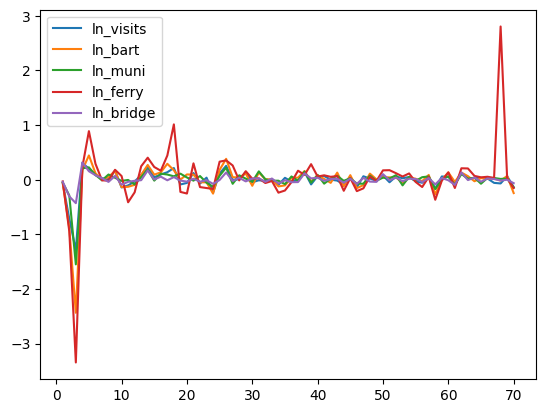

In [9]:
df_diff.plot()